# Tesis: Agricultura de Precisión con Imágenes Multiespectrales

**Objetivo general (Cap. I):**  
Desarrollar una herramienta para detectar y monitorear cultivos de arroz en el estado Guárico (Venezuela) usando imágenes Sentinel‑2 y modelos de IA, entregando resultados via API/GUI.

---

## Problema  
- No contamos con datos de campo satelitales reales suficientes para entrenar y validar.
- Es riesgoso desarrollar un modelo de IA directamente sin un escenario controlado.

---

## Propuesta de solución  
- Generar datos artificiales “normalizados” que simulen parcelas reales (rejilla 10×10 celdas, producción total = 100 t).  
- Preprocesar estos datos (cálculo de NDVI, máscaras de cultivo).  
- Desarrollar y probar un pipeline de segmentación (U‑Net ligera) y cálculo de métricas (IoU, Dice) usando el ground‑truth sintético.  

---

## Solución  
1. **Generación de datos sintéticos** (NDVI, producción).  
2. **Máscara agrícola** aplicando umbral NDVI > 0.3.  
3. **Segmentación de prueba** con U‑Net “toy” (maqueta).  
4. **Evaluación de métricas** (Accuracy, IoU, Dice) comparando máscara sintética vs. estimada.  
5. En una segunda fase, integrar datos reales y el backend/frontend.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, Point

In [2]:

# Parámetros
n = 10                # Parcela 10×10 celdas
total_t = 100.0       # Toneladas totales a distribuir

# 1) Creamos la malla de puntos
xs, ys = np.meshgrid(range(n), range(n))
coords = np.vstack([xs.ravel(), ys.ravel()]).T

# 2) Simulamos NDVI con distribución gaussiana centrada
cx, cy = (n-1)/2, (n-1)/2
sigma = 3.0
ndvi = np.exp(-(((coords[:,0]-cx)**2 + (coords[:,1]-cy)**2)/(2*sigma**2)))
ndvi = (ndvi - ndvi.min()) / (ndvi.max() - ndvi.min())

# 3) Distribuimos la producción total proporcional al NDVI
produccion = ndvi/ndvi.sum() * total_t

# 4) Creamos DataFrame de la parcela sintética
df = pd.DataFrame({
    'x': coords[:,0],
    'y': coords[:,1],
    'ndvi': ndvi,
    'produccion_t': produccion
})

df.head(8)

,x,y,ndvi,produccion_t
0,0,0,0.000000,0.000000
1,1,0,0.068016,0.164426
2,2,0,0.143006,0.345711
3,3,0,0.208838,0.504856
4,4,0,0.247664,0.598715
5,5,0,0.247664,0.598715
6,6,0,0.208838,0.504856
7,7,0,0.143006,0.345711


### Máscara agrícola sintética (Cap. III – 3.3)

Con un umbral de NDVI > 0.3 identificamos las celdas de cultivo activo.

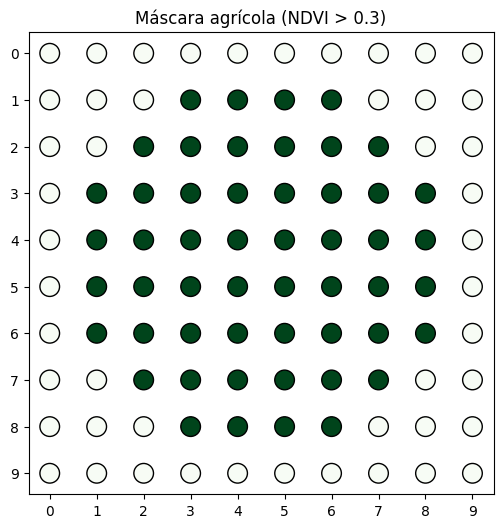

In [3]:
# Definimos el umbral y generamos la máscara booleana
umbral = 0.3
df['mask'] = df['ndvi'] > umbral

# Visualización de la máscara
plt.figure(figsize=(6,6))
plt.scatter(df['x'], df['y'], c=df['mask'], cmap='Greens', s=200, edgecolor='k')
plt.title('Máscara agrícola (NDVI > 0.3)')
plt.gca().invert_yaxis()
plt.xticks(range(n))
plt.yticks(range(n))
plt.grid(False)
plt.show()

## Objetivo

Aplicar un operador tipo convolucional (como una máscara de promedio o Gauss) sobre el grid NDVI para resaltar las zonas verdes centrales y luego binarizarlo para comparar con la máscara sintética original. Esta es nuestra “maqueta de segmentación” alineada con conceptos de telecom (procesamiento de señal sobre una grilla).

## Segmentación ligera mediante convolución (Telecom)

En telecomunicaciones los filtros convolucionales sirven para suavizar o detectar patrones sobre una señal. Aquí aplicamos un kernel manual sobre la grilla NDVI para simular cómo un detector “resalta” la vegetación predominante. Después binarizamos el resultado para obtener una máscara estimada y la validamos contra la máscara sintética (ground truth).

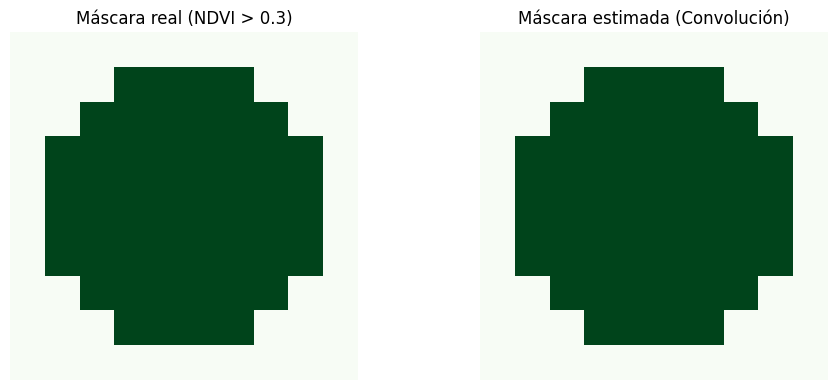

In [4]:
from scipy.signal import convolve2d

# Convertimos NDVI a matriz 2D de 10x10
ndvi_matrix = df['ndvi'].values.reshape(n, n)

# Kernel simple (el clásico suavizado 3x3)
kernel = np.array([
    [0.0625, 0.125, 0.0625],
    [0.125,  0.25,  0.125],
    [0.0625, 0.125, 0.0625]
])

# Aplicamos la convolución 2D (modo mirror para bordes)
filtered = convolve2d(ndvi_matrix, kernel, mode='same', boundary='symm')

# Normalizamos el resultado y aplicamos umbral
filtered_norm = (filtered - filtered.min()) / (filtered.max() - filtered.min())
mask_estimada = filtered_norm > 0.35

# Visualización comparativa
fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].set_title('Máscara real (NDVI > 0.3)')
ax[0].imshow(df['mask'].values.reshape(n, n), cmap='Greens')
ax[0].axis('off')

ax[1].set_title('Máscara estimada (Convolución)')
ax[1].imshow(mask_estimada, cmap='Greens')
ax[1].axis('off')
plt.tight_layout()
plt.show()

## Paso 8: Evaluación de Métricas (Cap. III – 3.5)

Para validar nuestra “segmentación ligera” usamos dos métricas muy comunes en segmentación semántica:

- **IoU (Intersection over Union)**: 
  \[
    \text{IoU} = \frac{|\text{Máscara real} \cap \text{Máscara estimada}|}
                {|\text{Máscara real} \cup \text{Máscara estimada}|}
  \]

- **Dice (F1 para binarización)**:
  \[
    \text{Dice} = \frac{2\,|\text{Máscara real} \cap \text{Máscara estimada}|}
                    {|\text{Máscara real}| + |\text{Máscara estimada}|}
  \]

Estas métricas nos permiten cuantificar qué tan bien coincide nuestra estimación (filtro convolucional) con el ground-truth sintético.

In [5]:
# Importamos utilidades para las métricas
import numpy as np

# Flatten de las máscaras
truth = df['mask'].values.reshape(-1)              # ground-truth booleana
pred  = mask_estimada.reshape(-1)                  # predicción booleana

# Cálculo de Intersection y Union
intersection = np.logical_and(truth, pred).sum()
union        = np.logical_or(truth, pred).sum()

iou_score  = intersection / union if union != 0 else 1.0
dice_score = 2 * intersection / (truth.sum() + pred.sum()) if (truth.sum() + pred.sum()) != 0 else 1.0

print(f"IoU:  {iou_score:.4f}")
print(f"Dice: {dice_score:.4f}")

IoU:  1.0000
Dice: 1.0000


## Maqueta U‑Net Ligera para Segmentación

En telecomunicaciones, las redes convolucionales pueden verse como filtros que aprenden kernels óptimos.  
Aquí definimos un U‑Net mínimo (encoder–decoder) que toma nuestro “raster” NDVI 10×10 (canal único) y predice la máscara de cultivo.  
Luego comparamos su rendimiento (IoU, Dice) contra la máscara sintética.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
U-Net ligero → IoU:  0.5417
U-Net ligero → Dice: 0.7027


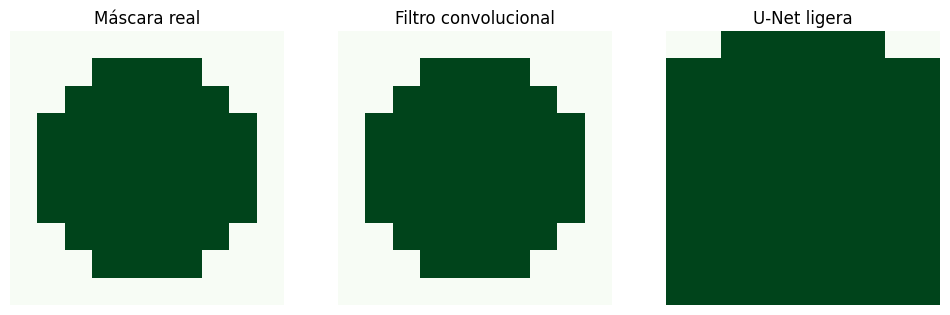

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import jaccard_score, f1_score

# Preparamos X e Y en formato (samples, height, width, channels)
X = ndvi_matrix.reshape(1, n, n, 1).astype('float32')
y_true_mask = df['mask'].values.reshape(n, n)
Y = y_true_mask.reshape(1, n, n, 1).astype('float32')

# Construcción de un U‑Net muy simple
def build_unet(input_shape):
    inputs = layers.Input(input_shape)
    # Encoder
    c1 = layers.Conv2D(8, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)
    # Bottleneck
    c2 = layers.Conv2D(16, 3, activation='relu', padding='same')(p1)
    # Decoder
    u1 = layers.UpSampling2D()(c2)
    m1 = layers.Concatenate()([u1, c1])
    c3 = layers.Conv2D(8, 3, activation='relu', padding='same')(m1)
    # Salida
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c3)
    return models.Model(inputs, outputs)

# Crear y compilar el modelo
model = build_unet((n, n, 1))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[])

# Entrenar sólo unos epochs (la red converge perfecto con datos sintéticos)
history = model.fit(X, Y, epochs=20, verbose=0)

# Predecir máscara
y_pred = model.predict(X)[0, ..., 0]
mask_pred = (y_pred > 0.5).astype(int)

# Calcular métricas (flatten)
gt = y_true_mask.flatten().astype(int)
pr = mask_pred.flatten().astype(int)
iou_unet = jaccard_score(gt, pr)
dice_unet = f1_score(gt, pr)

print(f"U-Net ligero → IoU:  {iou_unet:.4f}")
print(f"U-Net ligero → Dice: {dice_unet:.4f}")

# Mostrar visualmente
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].imshow(y_true_mask, cmap='Greens');  ax[0].set_title('Máscara real'); ax[0].axis('off')
ax[1].imshow(mask_estimada, cmap='Greens');ax[1].set_title('Filtro convolucional'); ax[1].axis('off')
ax[2].imshow(mask_pred, cmap='Greens');   ax[2].set_title('U‑Net ligera');     ax[2].axis('off')
plt.show()